In [1]:
import pandas as pd
from datasets import load_dataset

/home4/s6019595/.llmvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_aime = pd.read_csv("hf://datasets/di-zhang-fdu/AIME_1983_2024/AIME_Dataset_1983_2024.csv")
print(f"AIME: {len(df_aime)} problems")
print(f"Columns: {list(df_aime.columns)}")
df_aime.head()


AIME: 933 problems
Columns: ['ID', 'Year', 'Problem Number', 'Question', 'Answer', 'Part']


,ID,Year,Problem Number,Question,Answer,Part
0,1983-1,1983,1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,NaN
1,1983-2,1983,2,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,NaN
2,1983-3,1983,3,What is the product of the real roots of the e...,20,NaN
3,1983-4,1983,4,A machine-shop cutting tool has the shape of a...,26,NaN
4,1983-5,1983,5,Suppose that the sum of the squares of two com...,4,NaN


In [3]:
df_math = pd.read_parquet("hf://datasets/qwedsacf/competition_math/data/train-00000-of-00001-7320a6f3aba8ebd2.parquet")
print(f"MATH: {len(df_math)} problems")
print(f"Columns: {list(df_math.columns)}")
df_math.head()


MATH: 12500 problems
Columns: ['problem', 'level', 'type', 'solution']


,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...


In [4]:
df_math500 = pd.read_json("hf://datasets/HuggingFaceH4/MATH-500/test.jsonl", lines=True)
print(f"MATH-500: {len(df_math500)} problems")
print(f"Columns: {list(df_math500.columns)}")
df_math500.head()


MATH-500: 500 problems
Columns: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']


,problem,solution,answer,subject,level,unique_id
0,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,"\left( 3, \frac{\pi}{2} \right)",Precalculus,2,test/precalculus/807.json
1,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,p - q,Intermediate Algebra,5,test/intermediate_algebra/1994.json
2,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,\frac{14}{3},Algebra,3,test/algebra/2584.json
3,How many positive whole-number divisors does 1...,First prime factorize $196=2^2\cdot7^2$. The ...,9,Number Theory,3,test/number_theory/572.json
4,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,\text{Evelyn},Algebra,2,test/algebra/1349.json


In [5]:
math_questions = set(df_math['problem'])
math500_questions = set(df_math500['problem'])
common_questions = math_questions.intersection(math500_questions)
print(f"Number of common questions between MATH and MATH-500: {len(common_questions)}")

Number of common questions between MATH and MATH-500: 500


In [6]:
dataset_gsm8k = load_dataset("openai/gsm8k", "main", split="test")
df_gsm8k = pd.DataFrame(dataset_gsm8k)
print(f"GSM8K: {len(df_gsm8k)} problems")
print(f"Columns: {list(df_gsm8k.columns)}")
df_gsm8k.head()


GSM8K: 1319 problems
Columns: ['question', 'answer']


,question,answer
0,Janet’s ducks lay 16 eggs per day. She eats th...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...
1,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...
2,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...
3,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...
4,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t..."


In [7]:
dataset_olympiad = load_dataset("math-ai/olympiadbench") # option test_en, test_cn
df_olympiad = pd.DataFrame(dataset_olympiad["test"])
print(f"Olympiad: {len(df_olympiad)} problems")
print(f"Columns: {list(df_olympiad.columns)}")
df_olympiad.head()


Olympiad: 674 problems
Columns: ['id', 'question', 'solution', 'final_answer', 'context', 'image_1', 'image_2', 'image_3', 'image_4', 'image_5', 'modality', 'difficulty', 'is_multiple_answer', 'unit', 'answer_type', 'error', 'question_type', 'subfield', 'subject', 'language']


,id,question,solution,final_answer,context,image_1,image_2,image_3,image_4,image_5,modality,difficulty,is_multiple_answer,unit,answer_type,error,question_type,subfield,subject,language
0,1606,Xenia and Sergey play the following game. Xeni...,[Sergey can determine Xenia's number in 2 but ...,[2],None,None,None,None,None,None,Text-only,Competition,False,None,Numerical,None,Open-ended,Combinatorics,Math,English
1,1610,"Given a positive integer $n$, determine the la...",[The required maximum is $\frac{1}{2 n+2}$. To...,[$\frac{1}{2 n+2}$],None,None,None,None,None,None,Text-only,Competition,False,None,Expression,None,Open-ended,Algebra,Math,English
2,1612,\nFind (in closed form) the difference between...,"[For every integer $M \geq 0$, let $A_{M}=\sum...",[$2^{1009}$],None,None,None,None,None,None,Text-only,Competition,False,None,Numerical,None,Open-ended,Number Theory,Math,English
3,1613,Determine all positive integers $n$ satisfying...,"[There is only one such integer, namely, $n=2$...",[2],None,None,None,None,None,None,Text-only,Competition,False,None,Numerical,None,Open-ended,Algebra,Math,English
4,1614,Let $n$ be an integer greater than 1 and let $...,[The required maximum is $2 n-2$. To describe ...,[$2n-2$],None,None,None,None,None,None,Text-only,Competition,False,None,Expression,None,Open-ended,Combinatorics,Math,English


In [8]:
dataset_amc = load_dataset("math-ai/amc23")
df_amc = pd.DataFrame(dataset_amc['test'])
print(f"AMC: {len(df_amc)} problems")
print(f"Columns: {list(df_amc.columns)}")
df_amc.head()


AMC: 40 problems
Columns: ['id', 'question', 'answer', 'url']


,id,question,answer,url
0,0,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,https://artofproblemsolving.com/wiki/index.php...
1,1,Positive real numbers $x$ and $y$ satisfy $y^3...,36,https://artofproblemsolving.com/wiki/index.php...
2,2,What is the degree measure of the acute angle ...,45,https://artofproblemsolving.com/wiki/index.php...
3,3,What is the value of\n\[2^3 - 1^3 + 4^3 - 3^3 ...,3159,https://artofproblemsolving.com/wiki/index.php...
4,4,In a table tennis tournament every participant...,36,https://artofproblemsolving.com/wiki/index.php...


In [9]:
summary = pd.DataFrame({
    "Dataset": ["AIME", "MATH", "MATH-500", "GSM8K", "Olympiad", "AMC"],
    "Size": [len(df_aime), len(df_math), len(df_math500), len(df_gsm8k), len(df_olympiad), len(df_amc)],
})
summary

,Dataset,Size
0,AIME,933
1,MATH,12500
2,MATH-500,500
3,GSM8K,1319
4,Olympiad,674
5,AMC,40


In [10]:
print("AIME",list(df_aime.columns))
print("MATH",list(df_math.columns))
print("MATH 500",list(df_math500.columns))
print("GSM8K",list(df_gsm8k.columns))
print("Olympiad",list(df_olympiad.columns))
print("AMC",list(df_amc.columns))

AIME ['ID', 'Year', 'Problem Number', 'Question', 'Answer', 'Part']
MATH ['problem', 'level', 'type', 'solution']
MATH 500 ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']
GSM8K ['question', 'answer']
Olympiad ['id', 'question', 'solution', 'final_answer', 'context', 'image_1', 'image_2', 'image_3', 'image_4', 'image_5', 'modality', 'difficulty', 'is_multiple_answer', 'unit', 'answer_type', 'error', 'question_type', 'subfield', 'subject', 'language']
AMC ['id', 'question', 'answer', 'url']


In [11]:
#remove math500 duplicates from math
math_questions = set(df_math['problem'])
math500_questions = set(df_math500['problem'])  
common_questions = math_questions.intersection(math500_questions)
df_math = df_math[~df_math['problem'].isin(common_questions)]
print(f"After removing {len(common_questions)} duplicates, MATH now has {len(df_math)} problems.")

After removing 500 duplicates, MATH now has 12000 problems.


In [24]:
import pandas as pd

# Target schema
df_all = pd.DataFrame(columns=["dataset", "problem", "solution", "level"])

dfs = []

# TRAINING DATASETS

# AIME
dfs.append(pd.DataFrame({
    "dataset": "aime",
    "problem": df_aime["Question"],
    "solution": df_aime["Answer"],
    "level": None
}))

# MATH
dfs.append(pd.DataFrame({
    "dataset": "math",
    "problem": df_math["problem"],
    "solution": df_math["solution"],
    "level": df_math["level"]
}))

# EVALUATION DATASETS

# MATH-500
dfs.append(pd.DataFrame({
    "dataset": "math-500",
    "problem": df_math500["problem"],
    "solution": df_math500["solution"],  
    "level": df_math500["level"]
}))

# GSM8K
dfs.append(pd.DataFrame({
    "dataset": "gsm8k",
    "problem": df_gsm8k["question"],
    "solution": df_gsm8k["answer"],
    "level": None
}))

# Olympiad
dfs.append(pd.DataFrame({
    "dataset": "olympiad",
    "problem": df_olympiad["question"],
    "solution": df_olympiad["final_answer"],  
    "level": None
}))

# AMC
dfs.append(pd.DataFrame({
    "dataset": "amc",
    "problem": df_amc["question"],
    "solution": df_amc["answer"],
    "level": None
}))


df_all = pd.concat(dfs, ignore_index=True)


In [25]:
df_all = df_all.reset_index(drop=True)
df_all["id"] = df_all.index
df_all = df_all[["id", "dataset", "problem", "solution", "level"]]
print(f"Final combined dataframe: {len(df_all)} problems")
df_all.tail(5)

Final combined dataframe: 15466 problems


,id,dataset,problem,solution,level
15461,15461,amc,You are playing a game. A $2 \times 1$ rectang...,4,None
15462,15462,amc,When the roots of the polynomial \n\[P(x) = (...,6,None
15463,15463,amc,For how many integers $n$ does the expression\...,901,None
15464,15464,amc,"How many nonempty subsets $B$ of ${0, 1, 2, 3,...",144,None
15465,15465,amc,What is the area of the region in the coordina...,8,None


In [26]:
def normalize_solution(x):
    if isinstance(x, list):
        # join list elements into a single string
        return "\n".join(map(str, x))
    elif x is None:
        return None
    else:
        return str(x)

def normalize_level(x):
    """Remove "Level " prefix from level strings.
       Cast float levels to int
       set nan levels to None
    """
    if isinstance(x, str) and x.startswith("Level "):
        x = x.replace("Level ", "")
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    elif pd.isna(x):
        return None
    else:
        return str(x)

def deduplicate_dataframe(df):
    """Deduplicate dataframe based on 'problem' column."""
    before_dedup = len(df)
    df_dedup = df.drop_duplicates(subset=["problem"])
    after_dedup = len(df_dedup)
    print(f"Removed {before_dedup - after_dedup} duplicate problems. New size: {after_dedup}")
    return df_dedup

In [27]:
df_all["solution"] = df_all["solution"].apply(normalize_solution)
df_all["level"] = df_all["level"].apply(normalize_level)
df_all = deduplicate_dataframe(df_all)
#reset id column to be sequential



Removed 8 duplicate problems. New size: 15458


In [28]:
df_all.nunique()

id          15458
dataset         6
problem     15458
solution    14704
level           6
dtype: int64

In [29]:
#show unique levels
df_all["level"].unique()

array([None, '5', '3', '4', '1', '2', '?'], dtype=object)

In [30]:
#drop entries with level = "?"
df_all = df_all.drop(df_all[df_all["level"] == "?"].index)

In [31]:
#show unique levels
df_all["level"].unique()

array([None, '5', '3', '4', '1', '2'], dtype=object)

In [32]:
df_all = df_all.reset_index(drop=True)
df_all["id"] = df_all.index

In [33]:
#check if all ids are sequential
expected_ids = set(range(len(df_all)))
actual_ids = set(df_all['id'])


if expected_ids == actual_ids:
    print("All IDs are sequential and accounted for.")
else:
    missing_ids = expected_ids - actual_ids
    print(f"Missing IDs: {missing_ids}")


All IDs are sequential and accounted for.


In [34]:
df_all["dataset"].unique()

array(['aime', 'math', 'math-500', 'gsm8k', 'olympiad', 'amc'],
      dtype=object)

In [35]:
df_train = df_all[df_all["dataset"].isin(["aime", "math"])]
df_eval = df_all[df_all["dataset"].isin(["math-500", "gsm8k", "olympiad", "amc"])]

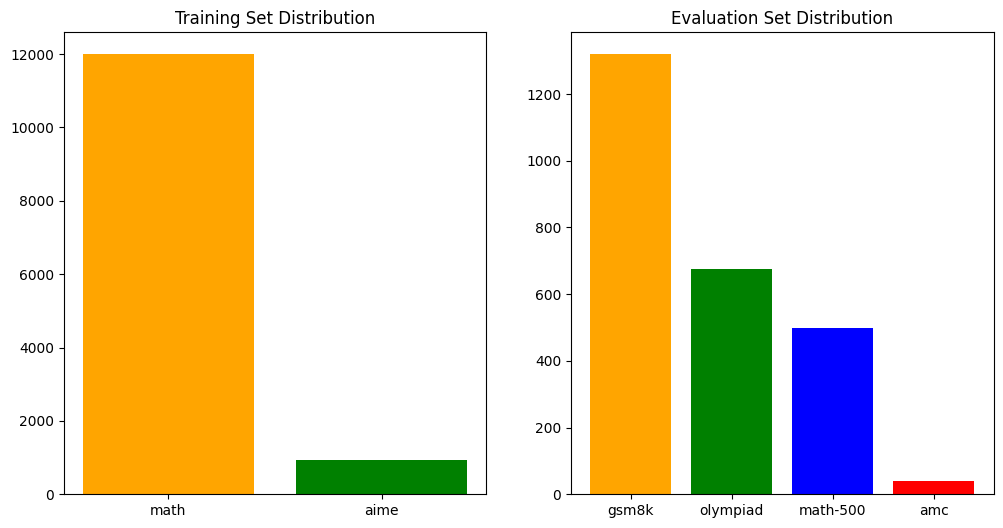

In [36]:
#Plot percentage of each dataset in train and eval sets
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1, 2, figsize=(12, 6))
train_counts = df_train["dataset"].value_counts()
axs[0].bar(train_counts.index, train_counts.values, color=['orange', 'green', 'blue', 'red'])
axs[0].set_title("Training Set Distribution")       
eval_counts = df_eval["dataset"].value_counts()
axs[1].bar(eval_counts.index, eval_counts.values, color=['orange', 'green', 'blue', 'red'])
axs[1].set_title("Evaluation Set Distribution")
plt.show()

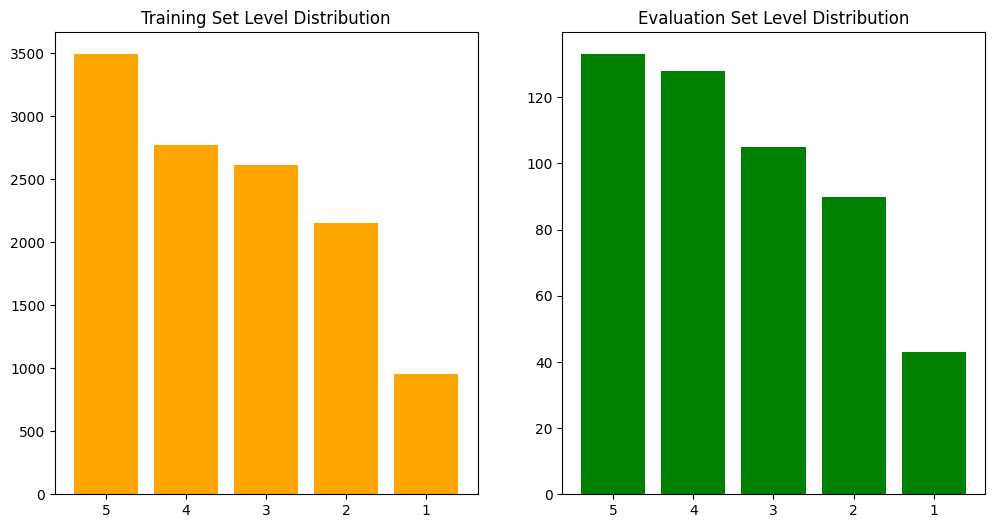

In [37]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
train_counts = df_train["level"].value_counts()
ax[0].bar(train_counts.index, train_counts.values, color='orange')
ax[0].set_title("Training Set Level Distribution")
eval_counts = df_eval["level"].value_counts()
ax[1].bar(eval_counts.index, eval_counts.values, color='green')
ax[1].set_title("Evaluation Set Level Distribution")
plt.show()

In [38]:
df_eval.head()

,id,dataset,problem,solution,level
12924,12924,math-500,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,2
12925,12925,math-500,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,5
12926,12926,math-500,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,3
12927,12927,math-500,How many positive whole-number divisors does 1...,First prime factorize $196=2^2\cdot7^2$. The ...,3
12928,12928,math-500,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,2


In [41]:
DATA_PATH = "/home4/s6019595/llm-think-too-much/data/"
df_train.to_parquet(f"{DATA_PATH}raw/train_data.parquet")
df_eval.to_parquet(f"{DATA_PATH}raw/eval_data.parquet")

In [42]:
df_eval[df_eval["dataset"] == "olympiad"].head()

,id,dataset,problem,solution,level
14742,14742,olympiad,Xenia and Sergey play the following game. Xeni...,2,None
14743,14743,olympiad,"Given a positive integer $n$, determine the la...",$\frac{1}{2 n+2}$,None
14744,14744,olympiad,\nFind (in closed form) the difference between...,$2^{1009}$,None
14745,14745,olympiad,Determine all positive integers $n$ satisfying...,2,None
14746,14746,olympiad,Let $n$ be an integer greater than 1 and let $...,$2n-2$,None


## POST GENERATION ANALYSIS EVAL

In [43]:
df_eval_gen = pd.read_parquet(f"{DATA_PATH}processed/eval/eval_test.parquet")
print(df_eval_gen.shape)
print(df_eval["dataset"].unique())
df_eval_gen.head(5)

(20, 13)
['math-500' 'gsm8k' 'olympiad' 'amc']


,id,dataset,level,prompt,solution_col,extracted_solution,extracted_generated_solution,is_correct,generated_think_text,generated_text,target_think_tokens,generated_think_tokens,latency_sec
0,15233,olympiad,None,"Let T be a rational number, and let $K=T-2$. I...",20,20,\dfrac{180,False,"Okay, find workers needed: (720/K) / 4 = 180/K...","Let T be a rational number, and let $K=T-2$. I...",100,40,18.035495
1,15233,olympiad,None,"Let T be a rational number, and let $K=T-2$. I...",20,20,320,False,"Okay, workers and time. More workers, more wid...","Let T be a rational number, and let $K=T-2$. I...",357,67,18.035495
2,15233,olympiad,None,"Let T be a rational number, and let $K=T-2$. I...",20,20,20,True,"Okay, so first, find K by subtracting 2 from T...","Let T be a rational number, and let $K=T-2$. I...",615,145,18.035495
3,15233,olympiad,None,"Let T be a rational number, and let $K=T-2$. I...",20,20,20,True,"Okay, so first, I need to figure out how many ...","Let T be a rational number, and let $K=T-2$. I...",873,275,18.035495
4,15233,olympiad,None,"Let T be a rational number, and let $K=T-2$. I...",20,20,20,True,"Okay, let's see. The problem says T is a ratio...","Let T be a rational number, and let $K=T-2$. I...",1131,423,18.035495


In [44]:
df_eval_gen["prompt"].iloc[0]

'Let T be a rational number, and let $K=T-2$. If $K$ workers can produce 9 widgets in 1 hour, compute the number of workers needed to produce $\\frac{720}{K}$ widgets in 4 hours. Let’s think step by step inside and output the final answer within boxed{}. Think for 100 tokens. <think>'

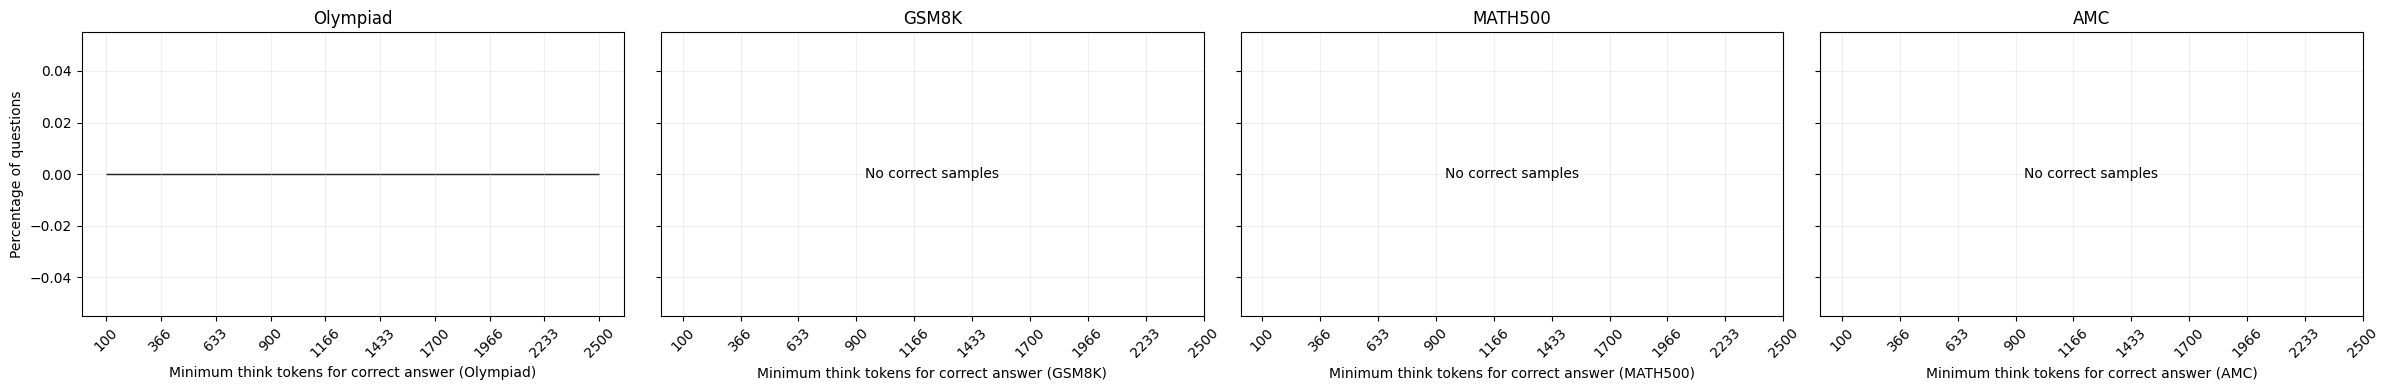

In [45]:
import numpy as np
import matplotlib.pyplot as plt

tokens = np.linspace(100, 2500, num=10).astype(int)
bins = tokens
# Min generated_think_tokens for correct answers, per dataset
min_tokens_olympiad = (
    df_eval_gen[(df_eval_gen["dataset"] == "olympiad") & (df_eval_gen["is_correct"] == True)]
    .groupby("id")["generated_think_tokens"].min()
    .dropna()
    .to_numpy()
)

min_tokens_gsm8k = (
    df_eval_gen[(df_eval_gen["dataset"] == "gsm8k") & (df_eval_gen["is_correct"] == True)]
    .groupby("id")["generated_think_tokens"].min()
    .dropna()
    .to_numpy()
)

min_tokens_math500 = (
    df_eval_gen[(df_eval_gen["dataset"] == "math-500") & (df_eval_gen["is_correct"] == True)]
    .groupby("id")["generated_think_tokens"].min()
    .dropna()
    .to_numpy()
)

min_tokens_amc = (
    df_eval_gen[(df_eval_gen["dataset"] == "amc") & (df_eval_gen["is_correct"] == True)]
    .groupby("id")["generated_think_tokens"].min()
    .dropna()
    .to_numpy()
)

fig, ax = plt.subplots(1, 4, figsize=(24, 4), sharey=True)

def plot_pct_hist(a, data, title, xlabel, color=None):
    if len(data) == 0:
        a.set_title(title)
        a.set_xlabel(xlabel)
        a.text(0.5, 0.5, "No correct samples", ha="center", va="center", transform=a.transAxes)
        a.set_xticks(tokens)
        a.grid(True, alpha=0.2)
        return

    a.hist(
        data,
        bins=bins,
        weights=np.ones_like(data) / len(data),
        edgecolor="black",
        color=color,
    )
    a.set_xticks(tokens)
    a.set_title(title)
    a.set_xlabel(xlabel)
    a.grid(True, alpha=0.2)

plot_pct_hist(ax[0], min_tokens_olympiad, "Olympiad", "Minimum think tokens for correct answer (Olympiad)")
plot_pct_hist(ax[1], min_tokens_gsm8k, "GSM8K", "Minimum think tokens for correct answer (GSM8K)", color="orange")
plot_pct_hist(ax[2], min_tokens_math500, "MATH500", "Minimum think tokens for correct answer (MATH500)", color="green")
plot_pct_hist(ax[3], min_tokens_amc, "AMC", "Minimum think tokens for correct answer (AMC)", color="red")

ax[0].set_ylabel("Percentage of questions")

for a in ax:
    a.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.savefig("dist-correct.pdf")
plt.show()


### Analysis why no correct samples

In [ ]:
import re

def extract_boxed(s: str) -> str | None:
    if not s:
        return None

    # MATH
    m = re.search(r"\\boxed\{([^}]*)\}", s)
    if m:
        return m.group(1).strip()

    # GSM8K
    matches = re.findall(
        r"(?m)^[ \t]*####[ \t]*([^\n\r#]+?)[ \t]*$",
        s
    )
    if matches:
        return matches[-1].strip()

    # Olympiad
    m = re.search(r"\$([^$]*)\$", s)
    if m:
        return m.group(1).strip()

    # AMC 
    m = re.search(r"(?m)^[ \t]*([+-]?\d+(?:\.\d+)?)[ \t]*$", s)
    if m:
        return m.group(1)

    return None


In [ ]:
df_eval_gen_gsm8k = df_eval_gen[df_eval_gen["dataset"] == "gsm8k"]
print(df_eval_gen_gsm8k.shape)
df_eval_gen_amc = df_eval_gen[df_eval_gen["dataset"] == "amc"]
print(df_eval_gen_amc.shape)

(26380, 13)
(800, 13)


In [ ]:
#print("Generated solution\n", df_eval_gen_gsm8k["generated_text"].iloc[0])
print("Solution column\n",df_eval_gen_gsm8k["solution_col"].iloc[2000])
print(extract_boxed(df_eval_gen_gsm8k["solution_col"].iloc[2000]))

Solution column
 The second friend pressed on the doorbell 1/4 times more than Jerome's first friend, a total of 1/4*20=<<1/4*20=5>>5 times.
Jerome's second friend pressed on the doorbell 20+5=<<20+5=25>>25
The first two friends pressed on the doorbell 25+20=<<25+20=45>>45 times altogether before Jerome could open the door.
Jerome's third friend pressed on the doorbell 60+10=<<60+10=70>>70 times before Jerome could open the door.
Altogether, Jerome's third and fourth friends pressed on the doorbell 70+60=<<70+60=130>>130 times before Jerome could open.
The number of doorbell rings that Jerome's friend made before Jerome could open the door is 130+45=<<130+45=175>>175 times.
#### 175
175


In [ ]:
#print("Generated solution\n", df_eval_gen_gsm8k["generated_text"].iloc[0])
print("Solution column\n",df_eval_gen_amc["solution_col"].iloc[0])
print(extract_boxed(df_eval_gen_amc["solution_col"].iloc[0]))
df_eval_gen_amc.head()

Solution column
 27
27


,id,dataset,level,prompt,solution_col,extracted_solution,extracted_generated_solution,is_correct,generated_think_text,generated_text,target_think_tokens,generated_think_tokens,latency_sec
78880,16868,amc,None,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,None,27,False,"Okay, so there's this problem where two cities...",Cities $A$ and $B$ are $45$ miles apart. Alici...,3968,2487,0.932885
78881,16868,amc,None,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,None,27,False,"Okay, so there's this problem where two cities...",Cities $A$ and $B$ are $45$ miles apart. Alici...,2163,1122,0.932885
78882,16868,amc,None,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,None,27,False,"Okay, let's see. So there are two cities, A an...",Cities $A$ and $B$ are $45$ miles apart. Alici...,1389,723,0.932885
78883,16868,amc,None,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,None,27,False,"Okay, their combined speed is 30 mph. Distance...",Cities $A$ and $B$ are $45$ miles apart. Alici...,357,61,0.932885
78884,16868,amc,None,Cities $A$ and $B$ are $45$ miles apart. Alici...,27,None,27,False,"Okay, so there's this problem where two cities...",Cities $A$ and $B$ are $45$ miles apart. Alici...,1647,959,0.932885


In [ ]:
import pandas as pd

def update_missing_groundtruth_extractions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Rows where GT extraction failed
    mask = df["extracted_solution"].isna()

    if mask.sum() == 0:
        return df

    # Re-extract from ground-truth solution column
    df.loc[mask, "extracted_solution"] = (
        df.loc[mask, "solution_col"].apply(extract_boxed)
    )

    # Normalization helper
    def normalize(x):
        if x is None or pd.isna(x):
            return None
        return str(x).strip()

    # Recompute correctness only for affected rows
    def safe_compare(row):
        gt = normalize(row["extracted_solution"])
        pred = normalize(row["extracted_generated_solution"])

        if gt is None:
            return False
        return gt == pred

    df.loc[mask, "is_correct"] = (
        df.loc[mask].apply(safe_compare, axis=1)
    )

    return df


In [ ]:
df_eval_gen_corrected = update_missing_groundtruth_extractions(df_eval_gen)
df_eval_gen_corrected[df_eval_gen_corrected["dataset"] == "olympiad"]["prompt"].iloc[0]

'Three circular arcs $\\gamma_{1}, \\gamma_{2}$, and $\\gamma_{3}$ connect the points $A$ and $C$. These arcs lie in the same half-plane defined by line $A C$ in such a way that $\\operatorname{arc} \\gamma_{2}$ lies between the $\\operatorname{arcs} \\gamma_{1}$ and $\\gamma_{3}$. Point $B$ lies on the segment $A C$. Let $h_{1}, h_{2}$, and $h_{3}$ be three rays starting at $B$, lying in the same half-plane, $h_{2}$ being between $h_{1}$ and $h_{3}$. For $i, j=1,2,3$, denote by $V_{i j}$ the point of intersection of $h_{i}$ and $\\gamma_{j}$ (see the Figure below).\n\nDenote by $\\overparen{V_{i j} V_{k j}} \\overparen{k_{k \\ell} V_{i \\ell}}$ the curved quadrilateral, whose sides are the segments $V_{i j} V_{i \\ell}, V_{k j} V_{k \\ell}$ and $\\operatorname{arcs} V_{i j} V_{k j}$ and $V_{i \\ell} V_{k \\ell}$. We say that this quadrilateral is circumscribed if there exists a circle touching these two segments and two arcs.\n\nProve that if the curved quadrilaterals $\\sqrt{V_{11} V

In [ ]:
df_eval_gen_corrected[df_eval_gen_corrected["dataset"] == "olympiad"].head(20)

,id,dataset,level,prompt,solution_col,extracted_solution,extracted_generated_solution,is_correct,generated_think_text,generated_text,target_think_tokens,generated_think_tokens,latency_sec
36360,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",1131,0,0.932885
36361,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{True,False,,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",357,0,0.932885
36362,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{True,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",1905,874,0.932885
36363,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{True,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",2936,1486,0.932885
36364,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",2678,1405,0.932885
36365,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",2163,1044,0.932885
36366,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",4226,2776,0.932885
36367,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",4484,2578,0.932885
36368,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",2421,1252,0.932885
36369,14742,olympiad,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",None,None,\text{The curved quadrilateral,False,"Okay, so I need to prove that if three specifi...","Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",3968,2257,0.932885


#### Adherence to the target per dataset

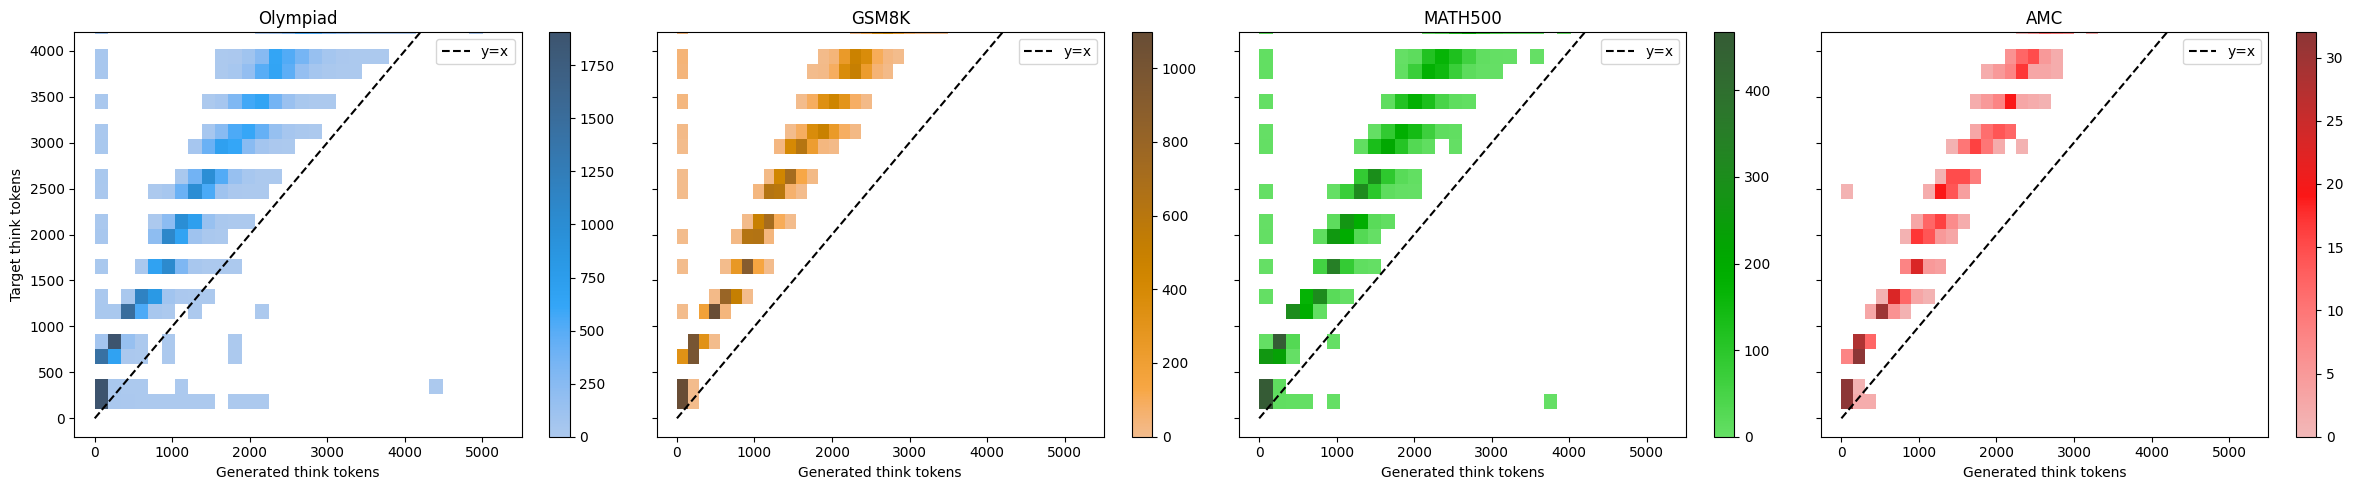

In [ ]:
import seaborn as sns

x = np.linspace(0, 5000, 3)

fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True, sharey=True)

df_olympiad = df_eval_gen[df_eval_gen["dataset"] == "olympiad"]
df_gsm8k    = df_eval_gen[df_eval_gen["dataset"] == "gsm8k"]
df_math500  = df_eval_gen[df_eval_gen["dataset"] == "math-500"]
df_amc      = df_eval_gen[df_eval_gen["dataset"] == "amc"]

def plot_2d_hist(ax, df_sub, title, color=None, show_ylabel=False):
    df_sub = df_sub[["generated_think_tokens", "target_think_tokens"]].dropna()
    if df_sub.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No samples", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel("Generated think tokens")
        ax.set_ylabel("Target think tokens" if show_ylabel else "")
        ax.set_ylim((-200, 4200))
        ax.plot(x, x, color="black", linestyle="dashed", label="y=x")
        ax.legend()
        return

    sns.histplot(
        df_sub,
        x="generated_think_tokens",
        y="target_think_tokens",
        bins=30,
        pmax=0.9,
        cbar=True,
        ax=ax,
        color=color,
    )
    ax.plot(x, x, color="black", linestyle="dashed", label="y=x")
    ax.set_title(title)
    ax.set_xlabel("Generated think tokens")
    ax.set_ylabel("Target think tokens" if show_ylabel else "")
    ax.set_ylim((-200, 4200))
    ax.legend()

plot_2d_hist(axes[0], df_olympiad, "Olympiad", show_ylabel=True)
plot_2d_hist(axes[1], df_gsm8k, "GSM8K", color="orange")
plot_2d_hist(axes[2], df_math500, "MATH500", color="green")
plot_2d_hist(axes[3], df_amc, "AMC", color="red")

plt.tight_layout()
plt.savefig("scatter.pdf")
plt.show()


# HIDDEN STATES GENERATION

In [46]:
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "/scratch/s6019595/models/L1-Qwen3-8B-Max/"
model_LCPO = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model_LCPO.eval()


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.48s/it]
The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 4096)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (down_proj): Linear(in_features=12288, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
        (post_attention_la

In [48]:
def generate_hidden_states(df):
    
    states = []
    states_ids = []

    for _, q in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Processing rows"):
       
        inputs = tokenizer(q["problem"], return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model_LCPO(**inputs, output_hidden_states=True)
        
        states.append(outputs.hidden_states[-1][:, -1, :].detach().to(torch.float16).cpu().numpy())
        states_ids.append(q["id"])

    states = np.stack(states, axis=0)
    states_ids = np.array(states_ids)

    return states, states_ids

### Generation of evaluation hidden states

In [49]:
print(df_eval["problem"].iloc[0])
print(df_eval.shape)
df_eval.head()

Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
(2532, 5)


,id,dataset,problem,solution,level
12924,12924,math-500,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,2
12925,12925,math-500,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,5
12926,12926,math-500,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,3
12927,12927,math-500,How many positive whole-number divisors does 1...,First prime factorize $196=2^2\cdot7^2$. The ...,3
12928,12928,math-500,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,2


In [50]:
eval_states, eval_states_ids = generate_hidden_states(df_eval)

Processing rows: 100%|██████████| 2532/2532 [03:26<00:00, 12.25it/s]


In [ ]:
np.save("/home4/s6019595/llm-think-too-much/data/processed/eval/hidden_states_eval.npy", eval_states)
np.save("/home4/s6019595/llm-think-too-much/data/processed/eval/hidden_state_ids_eval.npy", eval_states_ids)

### Generation of training hidden states

In [ ]:
print(df_train["problem"].iloc[0])
print(df_train.shape)
df_train.head()

Let $x$ , $y$ and $z$ all exceed $1$ and let $w$ be a positive number such that $\log_xw=24$ , $\log_y w = 40$ and $\log_{xyz}w=12$ . Find $\log_zw$ .
(12924, 5)


,id,dataset,problem,solution,level
0,0,aime,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,None
1,1,aime,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,None
2,2,aime,What is the product of the real roots of the e...,20,None
3,3,aime,A machine-shop cutting tool has the shape of a...,26,None
4,4,aime,Suppose that the sum of the squares of two com...,4,None


In [ ]:
train_states, train_states_ids = generate_hidden_states(df_train)

In [ ]:
np.save("/home4/s6019595/llm-think-too-much/data/processed/train/hidden_states_eval.npy", train_states)
np.save("/home4/s6019595/llm-think-too-much/data/processed/train/hidden_state_ids_eval.npy", train_states_ids)